# We begin by preparing the data.

## Opening the files and examining the data

The required libraries were imported to support data processing, modeling, and evaluation. Pandas and NumPy were used for data manipulation and numerical computations.
From scikit-learn, we imported evaluation tools such as mean_absolute_error and cross-validation utilities to assess model performance.
Two regression models were implemented: RandomForestRegressor, an ensemble method based on multiple decision trees, and LinearRegression as a baseline linear model.
Matplotlib was used for data visualization and exploratory analysis.

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

Rather than relying solely on the default scoring metrics provided by scikit-learn, a custom evaluation metric was implemented and integrated into the cross-validation process.
This approach ensures that model performance is assessed according to problem-specific criteria, allowing for a more accurate and meaningful evaluation aligned with the objectives of the industrial process.

In [2]:
from sklearn.metrics import make_scorer

In [3]:
ruta_train = '/datasets/gold_recovery_train.csv'
ruta_test = '/datasets/gold_recovery_test.csv'
ruta_full = '/datasets/gold_recovery_full.csv'
df_train = pd.read_csv(ruta_train)
df_test = pd.read_csv(ruta_test)
df_full = pd.read_csv(ruta_full)
dfs = [df_train, df_test, df_full]

The dataset was examined to understand its structure, feature composition, data types, and overall quality prior to modeling. This step ensured proper identification of missing values, variable distributions, and potential inconsistencies that could impact downstream analysis.

In [4]:
for df in dfs:
    print()
    print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                16860 non-null  object 
 1   final.output.concentrate_ag                         16788 non-null  float64
 2   final.output.concentrate_pb                         16788 non-null  float64
 3   final.output.concentrate_sol                        16490 non-null  float64
 4   final.output.concentrate_au                         16789 non-null  float64
 5   final.output.recovery                               15339 non-null  float64
 6   final.output.tail_ag                                16794 non-null  float64
 7   final.output.tail_pb                                16677 non-null  float64
 8   final.output.tail_sol                               16715 non-null  float64

In all DataFrames, we need to convert the date column to the appropriate data type and then sort the data chronologically to ensure it is properly organized for the analysis.

In [5]:
for df in dfs:
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date')


After completing the initial preprocessing steps, the datasets were separated to allow independent analysis and controlled experimentation. Working with each dataset individually improves clarity, reproducibility, and consistency throughout the modeling pipeline.

In [6]:
train = dfs[0]
test = dfs[1]
full = dfs[2]

## Recovery values were validated against the official process formula to confirm computational accuracy and data integrity prior to model development.

The number of missing values in the rougher.output.recovery column was quantified to assess target reliability prior to model development. Ensuring completeness of the target variable is critical for producing stable and unbiased predictive models.

In [7]:
train[['rougher.output.recovery',
          'final.output.recovery']].isnull().sum()

rougher.output.recovery    2573
final.output.recovery      1521
dtype: int64

Observations containing missing values in the target variable were removed to ensure clean and reliable labels for model training. This step prevents biased learning behavior and guarantees consistency during performance evaluation.

In [8]:
train = train.dropna(subset = (['rougher.output.recovery'])).copy()

Recovery was recalculated using the official process formula to validate consistency between the reported values and the theoretical definition of the metric.
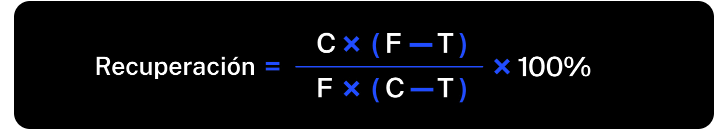


In [9]:

train['verif'] = (
    train['rougher.output.concentrate_au'] *
    (train['rougher.input.feed_au'] -
     train['rougher.output.tail_au'])
) / (
    train['rougher.input.feed_au'] *
    (train['rougher.output.concentrate_au'] -
     train['rougher.output.tail_au'])
) * 100

To assess the accuracy of the recalculated recovery values, the Mean Absolute Error (MAE) was computed between the theoretical calculation and the recorded recovery values.

In [10]:
mae = mean_absolute_error(train['rougher.output.recovery'], train['verif'])
mae

9.303415616264301e-15

The near-zero MAE indicates negligible deviation between the theoretical and recorded recovery values, validating computational accuracy and confirming data integrity for the target variable.

## Feature discrepancies between the training and test datasets were systematically analyzed to ensure consistent feature space definition and avoid information leakage during model evaluation.

A detailed comparison was conducted to determine which columns were present in the training dataset but absent in the test dataset.
The initial structural inspection revealed a discrepancy of approximately 30 features between the two datasets. Identifying these missing variables was essential to properly align the feature space and ensure consistency during model training and evaluation.

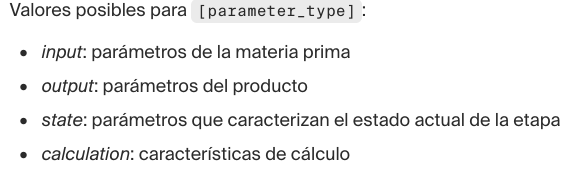

In [11]:
#To initiate the structural comparison, the total number of features in the training dataset was first quantified. This provided a baseline for identifying discrepancies between the training and test feature spaces.
len(train.columns)

88

In [12]:
len(test.columns)

53

In [13]:
train.columns[~train.columns.isin(test.columns)]

Index(['final.output.concentrate_ag', 'final.output.concentrate_pb',
       'final.output.concentrate_sol', 'final.output.concentrate_au',
       'final.output.recovery', 'final.output.tail_ag', 'final.output.tail_pb',
       'final.output.tail_sol', 'final.output.tail_au',
       'primary_cleaner.output.concentrate_ag',
       'primary_cleaner.output.concentrate_pb',
       'primary_cleaner.output.concentrate_sol',
       'primary_cleaner.output.concentrate_au',
       'primary_cleaner.output.tail_ag', 'primary_cleaner.output.tail_pb',
       'primary_cleaner.output.tail_sol', 'primary_cleaner.output.tail_au',
       'rougher.calculation.sulfate_to_au_concentrate',
       'rougher.calculation.floatbank10_sulfate_to_au_feed',
       'rougher.calculation.floatbank11_sulfate_to_au_feed',
       'rougher.calculation.au_pb_ratio', 'rougher.output.concentrate_ag',
       'rougher.output.concentrate_pb', 'rougher.output.concentrate_sol',
       'rougher.output.concentrate_au', 'rougher.outpu

The missing features primarily correspond to output variables and intermediate calculation parameters generated during the different processing stages of the plant.

## 1.4 Data Preprocessing and Feature Engineering

At this stage, each dataset was processed independently, starting with the training set to establish a clean and consistent foundation for model development.

Earlier, observations with missing values in rougher.output.recovery were removed from the training dataset. At this stage, rows with missing values in final.output.recovery were also excluded to ensure both target variables are complete and reliable for model training.

In [14]:
train = train.dropna(subset = ['final.output.recovery']).copy()

Next, we separate the two target variables.

In [15]:

y_final = train['final.output.recovery']
y_rougher = train['rougher.output.recovery']


To ensure consistency between the training and test datasets, their feature spaces were aligned. Only the features common to both datasets were retained, and the training set was filtered accordingly to guarantee structural consistency during model training and inference.

In [16]:
features = train.columns[train.columns.isin(test.columns)].drop('date')

Missing values were imputed using forward filling following chronological sorting. In continuous metallurgical operations, process variables exhibit temporal dependency, justifying the use of forward propagation to preserve process continuity and maintain realistic system behavior.

In [17]:
x_train = train.fillna(method='ffill').fillna(method='bfill')
train = train[features].fillna(method='ffill').fillna(method='bfill')
test = test.fillna(method='ffill').fillna(method='bfill')

Now we split the data into training and validation sets.

In [18]:
train.shape

(14149, 52)

In [19]:
test.shape

(5856, 53)

Given the time-series nature of the data, shuffling was intentionally avoided to preserve temporal dependencies. The dataset was split chronologically, using the first 80% for training and the remaining 20% for validation, thereby simulating real-world forecasting conditions and preventing look-ahead bias.

In [20]:

split = int(len(train) * 0.8)

features_train = train.iloc[:split]
features_valid = train.iloc[split:]

target_train_rougher = y_rougher.iloc[:split]
target_valid_rougher = y_rougher.iloc[split:]

target_train_final = y_final.iloc[:split]
target_valid_final = y_final.iloc[split:]


# Exploratory Data Analysis

## 2.1 The variation in gold (Au), silver (Ag), and lead (Pb) concentrations was analyzed across the different purification stages to evaluate process efficiency and metal enrichment behavior.

In [21]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 14149 entries, 0 to 16859
Data columns (total 88 columns):
 #   Column                                              Non-Null Count  Dtype         
---  ------                                              --------------  -----         
 0   date                                                14149 non-null  datetime64[ns]
 1   final.output.concentrate_ag                         14149 non-null  float64       
 2   final.output.concentrate_pb                         14149 non-null  float64       
 3   final.output.concentrate_sol                        14149 non-null  float64       
 4   final.output.concentrate_au                         14149 non-null  float64       
 5   final.output.recovery                               14149 non-null  float64       
 6   final.output.tail_ag                                14149 non-null  float64       
 7   final.output.tail_pb                                14149 non-null  float64       
 8   final.

Columns containing the keywords “au”, “ag”, and “pb” were selected to isolate variables related to metal concentrations. Additionally, the process flow diagram was used as a reference to identify features corresponding to key concentrate stages, specifically stages 1, 3, 5, and 8.

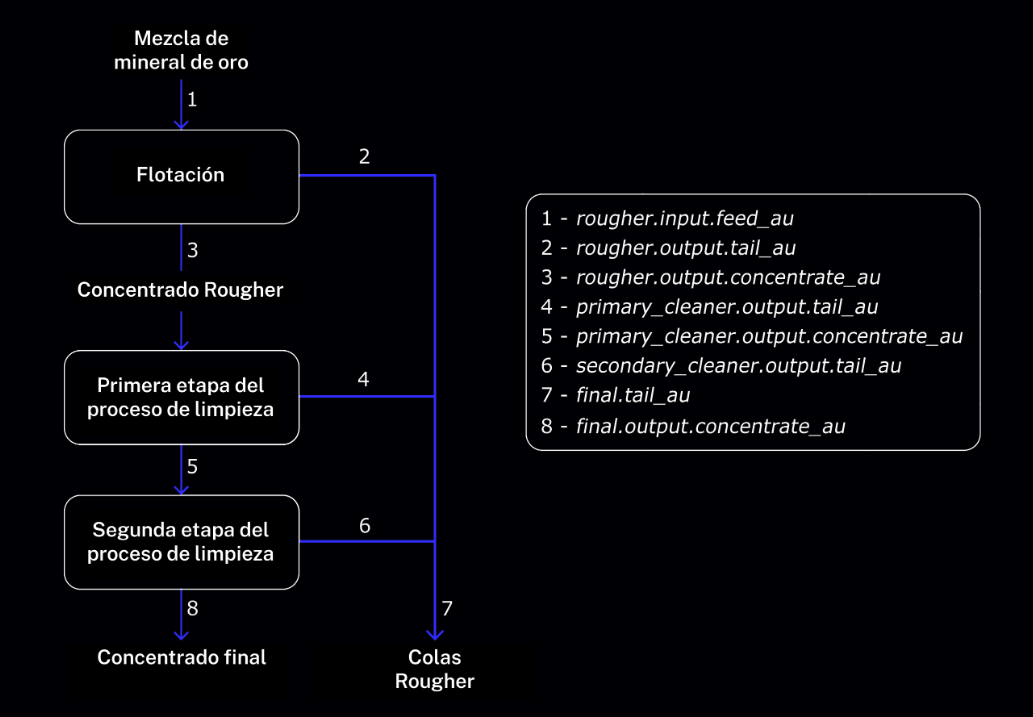

In [22]:
metals_conc = ['rougher.input.feed_', 'rougher.output.concentrate_', 'primary_cleaner.output.concentrate_', 'final.output.concentrate_']

metals = ['au', 'ag', 'pb']
columns = x_train.columns[x_train.columns.str.contains('|'.join(metals_conc)) &
    x_train.columns.str.contains('|'.join(metals))]


In [23]:
metals_conc = x_train[columns]

In [24]:
for metal in metals:
    print(metal)
    print(metals_conc[
    metals_conc.columns[metals_conc.columns.str.contains(metal)]
].mean())
    


au
final.output.concentrate_au              44.003792
primary_cleaner.output.concentrate_au    32.386836
rougher.input.feed_au                     7.866577
rougher.output.concentrate_au            19.439958
dtype: float64
ag
final.output.concentrate_ag               5.141921
primary_cleaner.output.concentrate_ag     8.200916
rougher.input.feed_ag                     8.579195
rougher.output.concentrate_ag            11.775812
dtype: float64
pb
final.output.concentrate_pb              10.132848
primary_cleaner.output.concentrate_pb     9.568544
rougher.input.feed_pb                     3.505465
rougher.output.concentrate_pb             7.664555
dtype: float64


Gold and lead concentrations show a consistent upward trend across successive purification stages, indicating effective enrichment throughout the process.
In contrast, silver exhibits a different behavior: its concentration increases during the second stage but gradually declines in the later stages, suggesting distinct metallurgical dynamics compared to gold and lead.

## 2.2. To ensure reliable model evaluation, the feed particle size distributions were compared between the training and test datasets. Detecting significant distributional shifts is critical, as substantial divergence would indicate potential data drift and compromise the validity of model performance estimates.

In [25]:
x_train[x_train.columns[x_train.columns.str.contains('feed_size')]]

,primary_cleaner.input.feed_size,rougher.input.feed_size
0,7.25,55.486599
1,7.25,57.278666
2,7.25,57.510649
3,7.25,57.792734
4,7.25,56.047189
...,...,...
16855,6.50,85.718304
16856,6.50,119.499241
16857,6.50,122.262690
16858,6.50,123.742430


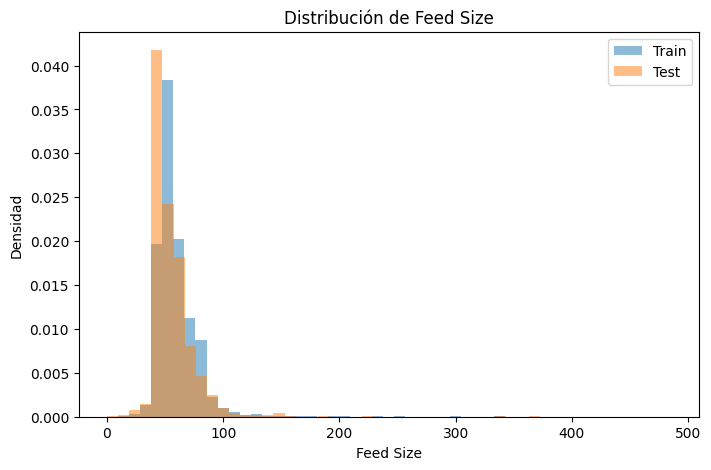

In [26]:
plt.figure(figsize=(8,5))

plt.hist(x_train['rougher.input.feed_size'],
         bins=50,
         alpha=0.5,
         label='Train',
         density=True)

plt.hist(test['rougher.input.feed_size'],
         bins=50,
         alpha=0.5,
         label='Test',
         density=True)

plt.legend()
plt.title('Distribución de Feed Size')
plt.xlabel('Feed Size')
plt.ylabel('Densidad')
plt.show()

In [27]:
x_train['rougher.input.feed_size'].mean()

60.23985599255732

In [28]:
test['rougher.input.feed_size'].mean()

55.89886568885065

The distributions are quite similar between the training and test datasets.

## 2.3.

In [29]:
x_train['total_feed'] = (
    x_train['rougher.input.feed_au'] +
    x_train['rougher.input.feed_ag'] +
    x_train['rougher.input.feed_pb'] +
    x_train['rougher.input.feed_sol']
)

In [30]:
x_train['total_rougher'] = (
    x_train['rougher.output.concentrate_au'] +
    x_train['rougher.output.concentrate_ag'] +
    x_train['rougher.output.concentrate_pb'] +
    x_train['rougher.output.concentrate_sol']
)

In [31]:
x_train['total_final'] = (
    x_train['final.output.concentrate_au'] +
    x_train['final.output.concentrate_ag'] +
    x_train['final.output.concentrate_pb'] +
    x_train['final.output.concentrate_sol']
)

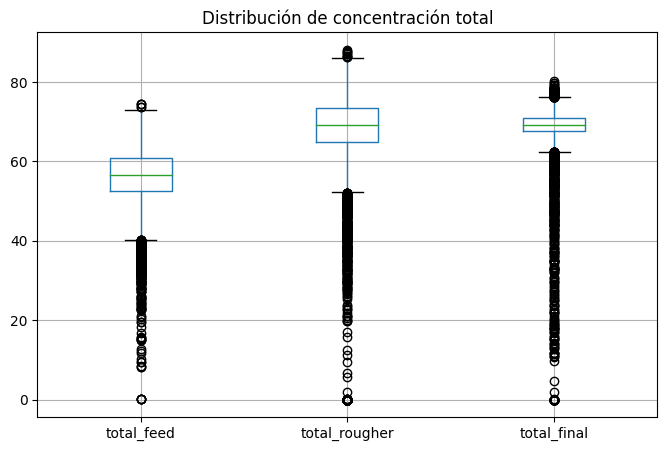

In [32]:
x_train[['total_feed','total_rougher','total_final']].boxplot(figsize=(8,5))
plt.title('Distribución de concentración total')
plt.show()

In [33]:
x_train[['total_feed','total_rougher','total_final']].describe()

,total_feed,total_rougher,total_final
count,14149.000000,14149.000000,14149.000000
mean,56.242170,67.173145,68.387872
std,7.029808,12.713129,7.023723
min,0.040000,0.000000,0.000000
25%,52.573579,64.914390,67.559819
50%,56.627635,69.175663,69.141502
75%,60.763234,73.429261,70.974661
max,74.458253,88.140119,80.210644


In [34]:
x_train['total_feed'].quantile(0.01)

33.943033296176786

Values close to zero were treated as abnormal observations and removed from the dataset. Based on distribution analysis and evaluation of the 1st percentile, a minimum concentration threshold of 15 was selected as a reasonable cutoff to filter unrealistic process measurements.

In [35]:
condicion = (
    (x_train['total_feed'] > 10) &
    (x_train['total_rougher'] > 10) &
    (x_train['total_final'] > 10)
)

In [36]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 14149 entries, 0 to 16859
Data columns (total 91 columns):
 #   Column                                              Non-Null Count  Dtype         
---  ------                                              --------------  -----         
 0   date                                                14149 non-null  datetime64[ns]
 1   final.output.concentrate_ag                         14149 non-null  float64       
 2   final.output.concentrate_pb                         14149 non-null  float64       
 3   final.output.concentrate_sol                        14149 non-null  float64       
 4   final.output.concentrate_au                         14149 non-null  float64       
 5   final.output.recovery                               14149 non-null  float64       
 6   final.output.tail_ag                                14149 non-null  float64       
 7   final.output.tail_pb                                14149 non-null  float64       
 8   final.

In [37]:
x_train = x_train[condicion]

In [38]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 13783 entries, 0 to 16859
Data columns (total 91 columns):
 #   Column                                              Non-Null Count  Dtype         
---  ------                                              --------------  -----         
 0   date                                                13783 non-null  datetime64[ns]
 1   final.output.concentrate_ag                         13783 non-null  float64       
 2   final.output.concentrate_pb                         13783 non-null  float64       
 3   final.output.concentrate_sol                        13783 non-null  float64       
 4   final.output.concentrate_au                         13783 non-null  float64       
 5   final.output.recovery                               13783 non-null  float64       
 6   final.output.tail_ag                                13783 non-null  float64       
 7   final.output.tail_pb                                13783 non-null  float64       
 8   final.

In [39]:
#We separate the target variables.
y_final = x_train['final.output.recovery']
y_rougher = x_train['rougher.output.recovery']
#We fill the missing values.
x_train = x_train[features].fillna(method='ffill').fillna(method='bfill')
#We divide the dataset into training and validation sets, handling each target variable independently.
split = int(len(train) * 0.8)

features_train = x_train.iloc[:split]
features_valid = x_train.iloc[split:]

target_train_rougher = y_rougher.iloc[:split]
target_valid_rougher = y_rougher.iloc[split:]

target_train_final = y_final.iloc[:split]
target_valid_final = y_final.iloc[split:]


# 3. Model Development

## 3.1. A custom function was defined to compute the final sMAPE evaluation metric.

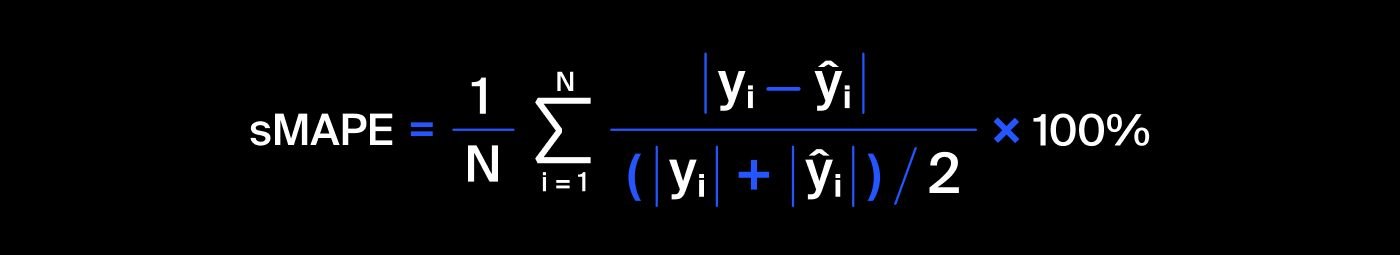
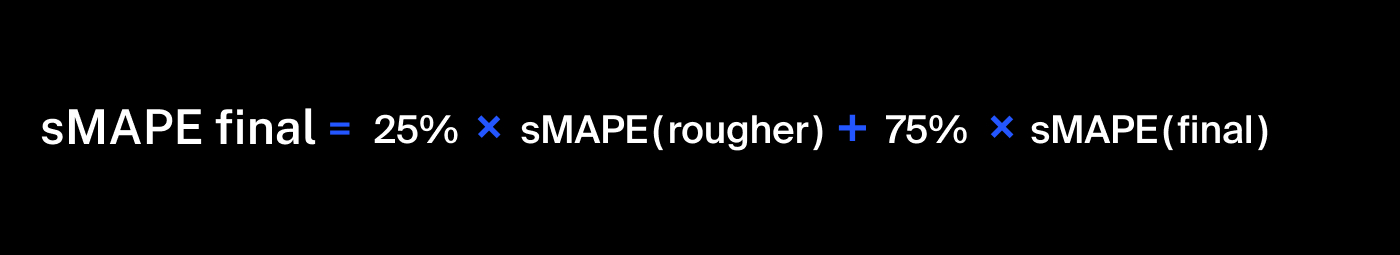


In [40]:

def smape(y_true, y_pred):
    #sMAPE en porcentaje. y_true, y_pred: array-like (pd.Series, np.array, list)
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0

    # Evita división entre 0 cuando y_true=y_pred=0
    # En ese caso, el término debe contribuir 0 al promedio.
    fraction = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator != 0)

    return 100 * np.mean(fraction)


def final_metric_smape(smape_rougher, smape_final):
    return 0.25 * smape_rougher + 0.75 * smape_final


## 3.2. Multiple models were trained and evaluated using cross-validation to ensure robust performance assessment. After comparing validation metrics, the best-performing model was selected and evaluated on the test dataset. Final results were then reported based on the defined evaluation criteria.

In [41]:
model1 = RandomForestRegressor(random_state = 12345)
model2 = LinearRegression()

Metemos nuestra metrica a la validacion cruzada

In [42]:
custom_scorer = make_scorer(smape, greater_is_better=False)

We tested the Random Forest model.

In [43]:
#We test the model for rougher.output.recovery.
smape_rougher = cross_val_score(model1, x_train, y_rougher, cv=5, scoring=custom_scorer)
smape_rougher

array([-8.78800275, -7.41975268, -4.81383567, -6.32135275, -8.70875222])

In [44]:
#We test the model for final.output.recovery.
smape_final = cross_val_score(model1, x_train, y_final, cv=5, scoring=custom_scorer)
smape_final


array([ -9.61312617, -10.51545617,  -9.15197587,  -9.37967501,
       -10.74637883])

In [45]:
smape_Final = final_metric_smape(smape_rougher, smape_final)
smape_Final

array([ -9.40684532,  -9.7415303 ,  -8.06744082,  -8.61509445,
       -10.23697217])

We tested the Linear Regression model.

In [46]:
#We evaluated the model’s performance for predicting rougher recovery.
smape_rougher_lin = cross_val_score(model2, x_train, y_rougher, cv=5, scoring=custom_scorer)
smape_rougher_lin

array([-9.54682739, -7.17399164, -5.57661951, -4.73047781, -9.10762896])

In [47]:
#We evaluated the model’s performance for predicting final recovery.
smape_final_lin = cross_val_score(model2, x_train, y_final, cv=5, scoring=custom_scorer)
smape_final_lin 

array([-13.11877363,  -9.3197757 ,  -9.3814178 ,  -9.12857721,
       -13.86990165])

In [48]:
#Now we calculate the final sMAPE.
smape_Final_lin = final_metric_smape(smape_rougher_lin, smape_final_lin)
smape_Final_lin

array([-12.22578707,  -8.78332969,  -8.43021823,  -8.02905236,
       -12.67933348])

In [49]:
smape_Final.mean()

-9.213576611393123

In [50]:
smape_Final_lin.mean()

-10.02954416638225

### The selected best-performing model was then evaluated on the test dataset to assess its generalization capability under unseen conditions.

In [51]:
model_rougher = RandomForestRegressor(
    random_state=123
)

model_final = RandomForestRegressor(
    random_state=123
)

model_rougher.fit(x_train, y_rougher)
model_final.fit(x_train, y_final)

RandomForestRegressor(random_state=123)

In [53]:
x_test = test[features]
pred_rougher_test = model_rougher.predict(x_test)
pred_final_test = model_final.predict(x_test)

In [55]:
pred_rougher_test.size

5856

In [56]:
pred_final_test.size

5856

In [58]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5856 entries, 0 to 5855
Data columns (total 53 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   date                                        5856 non-null   datetime64[ns]
 1   primary_cleaner.input.sulfate               5856 non-null   float64       
 2   primary_cleaner.input.depressant            5856 non-null   float64       
 3   primary_cleaner.input.feed_size             5856 non-null   float64       
 4   primary_cleaner.input.xanthate              5856 non-null   float64       
 5   primary_cleaner.state.floatbank8_a_air      5856 non-null   float64       
 6   primary_cleaner.state.floatbank8_a_level    5856 non-null   float64       
 7   primary_cleaner.state.floatbank8_b_air      5856 non-null   float64       
 8   primary_cleaner.state.floatbank8_b_level    5856 non-null   float64       
 9   primary_

In [60]:
results_test = test.copy()
results_test["pred_rougher"] = pred_rougher_test
results_test["pred_final"] = pred_final_test

The dataframes were merged using an inner join on the date column to ensure proper alignment between observations. This approach enables direct comparison between true values and model predictions while preserving only matching timestamps.

In [64]:
merged = full.merge(
    results_test[["date", "pred_rougher", "pred_final"]],
    on="date",
    how="inner"
)

In [65]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5856 entries, 0 to 5855
Data columns (total 89 columns):
 #   Column                                              Non-Null Count  Dtype         
---  ------                                              --------------  -----         
 0   date                                                5856 non-null   datetime64[ns]
 1   final.output.concentrate_ag                         5839 non-null   float64       
 2   final.output.concentrate_pb                         5841 non-null   float64       
 3   final.output.concentrate_sol                        5841 non-null   float64       
 4   final.output.concentrate_au                         5841 non-null   float64       
 5   final.output.recovery                               5414 non-null   float64       
 6   final.output.tail_ag                                5839 non-null   float64       
 7   final.output.tail_pb                                5839 non-null   float64       
 8   final.ou

The relevant columns were selected, and both the sMAPE and final weighted sMAPE metrics were computed. These metrics provide a comprehensive assessment of model performance and enable objective evaluation based on the defined criteria.

In [67]:
# 'rougher.output.recovery', 'final.output.recovery', 'pred_rougher', 'pred_final'
cols_needed = ["rougher.output.recovery", "final.output.recovery", "pred_rougher", "pred_final"]
df_eval = merged.dropna(subset=cols_needed).copy()

smape_rough = smape(df_eval["rougher.output.recovery"], df_eval["pred_rougher"])
smape_final = smape(df_eval["final.output.recovery"], df_eval["pred_final"])

final_score = final_metric_smape(smape_rough, smape_final)

print("SMAPE rougher:", smape_rough)
print("SMAPE final:", smape_final)
print("Final metric:", final_score)
print("Filas usadas:", len(df_eval), "de", len(df))

SMAPE rougher: 7.937233056895194
SMAPE final: 9.742137191760092
Final metric: 9.290911158043867
Filas usadas: 5290 de 22716


Conclusion
With a final sMAPE below 10%, the model demonstrates strong predictive accuracy. These results indicate that the Random Forest Regressor effectively captures the complex nonlinear relationships inherent in industrial recovery processes.